# 02 GenAI Implementation (Mid)

## Objective
Add embeddings, retrieval, and golden-prompt evaluation on top of a basic generation pipeline.

## Run order
1. Setup imports and repo path.
2. Load config (YAML).
3. Download nongated Hugging Face models (generation + embeddings).
4. Build a tiny retrieval corpus and compute embeddings.
5. Retrieve relevant context and generate an answer.
6. Evaluate with golden prompts + visualize retrieval scores.

## Notes
- This notebook downloads nongated models from Hugging Face on first run.
- CPU-only by default (config controls device/dtype).

In [3]:
# stdlib pathlib (filesystem paths)
from pathlib import Path

# stdlib sys (Python path management)
import sys

# stdlib json (write outputs)
import json

# numpy (numeric arrays)
import numpy as np

# matplotlib (visualization)
import matplotlib.pyplot as plt

# scikit-learn cosine similarity (vector similarity)
from sklearn.metrics.pairwise import cosine_similarity

# Bootstrap repo root on sys.path so `import src...` works from notebooks.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
if (repo_root / "src").exists() and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# src/utils/pathing.py
from src.utils.pathing import ensure_repo_root_on_sys_path  # src/utils/pathing.py

# src/llm/config.py
from src.llm.config import load_llm_config  # src/llm/config.py
# src/llm/model_loading.py
from src.llm.model_loading import (  # src/llm/model_loading.py
    load_embedding_model,
    load_generation_model,
)
# src/llm/tokenization.py
from src.llm.tokenization import load_tokenizer  # src/llm/tokenization.py
# src/llm/generation.py
from src.llm.generation import generate_text  # src/llm/generation.py
# src/llm/eval.py
from src.llm.eval import GoldenPromptCase, evaluate_golden_prompts  # src/llm/eval.py
# src/llm/telemetry.py
from src.llm.telemetry import (  # src/llm/telemetry.py
    TimingContext,
    build_token_usage_record,
    log_token_usage,
    utc_timestamp,
)

repo_root = ensure_repo_root_on_sys_path(Path.cwd())

In [4]:
config_path = repo_root / "config" / "llm_interview.yaml"
config = load_llm_config(config_path)

run_timestamp = utc_timestamp()
logs_dir = Path(config.logging.logs_dir)
results_dir = Path(config.logging.results_dir)

token_log_path = logs_dir / f"llm_tokens_{run_timestamp}.jsonl"
timing_log_path = logs_dir / f"llm_timing_{run_timestamp}.jsonl"
results_path = results_dir / f"genai_eval_{run_timestamp}.json"

logs_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

config

LLMConfig(run_id='genai_interview', seed=42, model=ModelConfig(model_id='google/gemma-3-1b-it', tokenizer_id='google/gemma-3-1b-it', revision=None), embeddings=EmbeddingConfig(model_id='sentence-transformers/paraphrase-MiniLM-L3-v2'), device=DeviceConfig(device_strategy='cpu', device_map='cpu', torch_dtype='float32', quantization='none'), tokenization=TokenizationConfig(padding='max_length', truncation=True, max_length=128), generation=GenerationConfig(max_new_tokens=64, temperature=0.7, top_p=0.9, top_k=50, repetition_penalty=1.1, do_sample=True), logging=LoggingConfig(output_root='outputs', logs_dir='outputs/logs', results_dir='outputs/results'))

In [5]:
with TimingContext(
    log_path=timing_log_path,
    run_id=config.run_id,
    model_id=config.model.model_id,
    step_name="model_and_tokenizer_load",
    device=config.device.device_strategy,
    torch_dtype=config.device.torch_dtype,
):
    tokenizer = load_tokenizer(config)
    model = load_generation_model(config)

with TimingContext(
    log_path=timing_log_path,
    run_id=config.run_id,
    model_id=config.embeddings.model_id,
    step_name="embedding_model_load",
    device=config.device.device_strategy,
    torch_dtype=config.device.torch_dtype,
):
    embedding_model = load_embedding_model(config)

model

`torch_dtype` is deprecated! Use `dtype` instead!


Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 1152, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear(in_features=1152, out_features=1024, bias=False)
          (k_proj): Linear(in_features=1152, out_features=256, bias=False)
          (v_proj): Linear(in_features=1152, out_features=256, bias=False)
          (o_proj): Linear(in_features=1024, out_features=1152, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear(in_features=1152, out_features=6912, bias=False)
          (up_proj): Linear(in_features=1152, out_features=6912, bias=False)
          (down_proj): Linear(in_features=6912, out_features=1152, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma3RMSNorm((1152,), e

In [6]:
corpus = [
    "Reproducibility in ML means the same inputs yield the same outputs.",
    "Tokenization splits text into model-friendly pieces.",
    "RAG improves factuality by grounding answers in retrieved context.",
    "Determinism can be affected by GPU kernel nondeterminism.",
]

query = "Why is RAG helpful for factuality?"

corpus_embeddings = embedding_model.encode(corpus, convert_to_numpy=True)
query_embedding = embedding_model.encode([query], convert_to_numpy=True)

similarities = cosine_similarity(query_embedding, corpus_embeddings)[0]
ranked_indices = np.argsort(similarities)[::-1]

retrieved_text = corpus[ranked_indices[0]]
retrieved_text

'RAG improves factuality by grounding answers in retrieved context.'

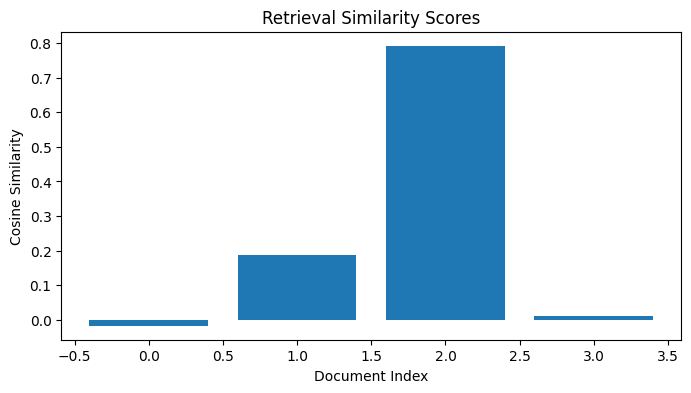

In [7]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(similarities)), similarities)
plt.title("Retrieval Similarity Scores")
plt.xlabel("Document Index")
plt.ylabel("Cosine Similarity")
plt.show()

In [8]:
prompt = (
    "Use the context to answer the question.\n"
    f"Context: {retrieved_text}\n"
    f"Question: {query}\n"
    "Answer:"
)

result = generate_text(model, tokenizer, prompt, config)

record = build_token_usage_record(
    generation_result=result,
    run_id=config.run_id,
    model_id=config.model.model_id,
    task_name="rag_answer",
    input_ref=str(config_path),
    output_ref=str(results_path),
)
log_token_usage(token_log_path, record)

result.output_text

'Use the context to answer the question.\nContext: RAG improves factuality by grounding answers in retrieved context.\nQuestion: Why is RAG helpful for factuality?\nAnswer: Because it grounds answers in retrieved context.\n\nFinal Answer: The final answer is $\\boxed{Because it grounds answers in retrieved context.}$'

In [9]:
golden_fixture_path = (
    repo_root
    / "Interview"
    / "Generative"
    / "golden_prompts_fixture.json"
)
fixture_payload = json.loads(golden_fixture_path.read_text(encoding="utf-8"))

golden_cases = [
    GoldenPromptCase(
        prompt=item["prompt"],
        expected_substrings=item["expected_substrings"],
        forbidden_substrings=item["forbidden_substrings"],
    )
    for item in fixture_payload[:1]
]

eval_summary = evaluate_golden_prompts(golden_cases, [result.output_text])
results_payload = {
    "retrieved_text": retrieved_text,
    "generation": result.output_text,
    "evaluation": eval_summary,
}
results_path.write_text(json.dumps(results_payload, indent=2), encoding="utf-8")

eval_summary

{'pass_rate': 0.0,
 'total_cases': 1,
 'results': [{'prompt': 'Why is reproducibility important in ML?',
   'expected_hits': [],
   'forbidden_hits': [],
   'passed': False}]}